# MNIST


In [5]:
import ssl

import onnx
import torch
import torchviz
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


Train samples: 60000
Test samples:  10000
Input shape:   torch.Size([1, 28, 28])
Classes:       ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
First sample:  (tensor([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242

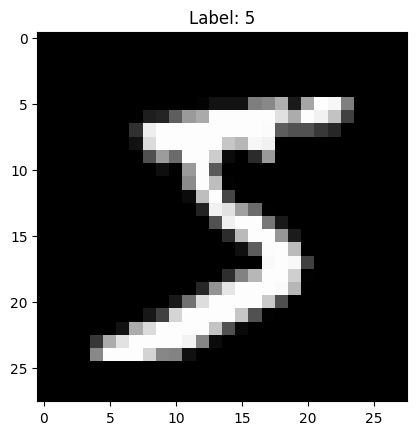

In [6]:

ssl._create_default_https_context = ssl._create_unverified_context

# define a transform to normalize the data
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean and std
    ]
)

train_dataset = datasets.MNIST(
    root="../data", train=True, transform=transform, download=True
)
test_dataset = datasets.MNIST(
    root="../data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Input shape:   {train_dataset[0][0].shape}")
print(f"Classes:       {train_dataset.classes}")


# print first sample
print(f"First sample:  {train_dataset[0]}")

# visualize first sample
import matplotlib.pyplot as plt
plt.imshow(train_dataset[0][0].squeeze(), cmap="gray")
plt.title(f"Label: {train_dataset[0][1]}")
plt.show()

In [7]:
# lets create the dataloader 
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

for batch_labels, batch_images in train_loader:
    print(f"Batch labels: {batch_labels}")
    print(f"Batch images shape: {batch_images.shape}")
    break

Batch labels: tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-

"""
nn.sequnetial(
    nn.linear(28*28, 64),
    nn.relu(64,32),
    nn.linear(32,10),
    nn.softmax()
)
"""

In [14]:
from torch import nn
import torch    
model = nn.Sequential(
    nn.Linear(28*28, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10),
)
optmizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()
epochs = 10

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for i in range(epochs):
    for batch_images, batch_labels in train_loader:
        optmizer.zero_grad()
        batch_images = batch_images.view(batch_images.size(0), -1)  # flatten
        # print shape
        print(f"Batch images shape: {batch_images.shape}")
        print(f"Batch labels shape: {batch_labels.shape}")

        predictions = model(batch_images)
        loss = criterion(predictions, batch_labels)
        loss.backward()
        optimizer.step()
        print(f"Epoch {i+1}/{epochs}, Loss: {loss.item():.4f}")

Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.3093
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.3219
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.3056
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.3069
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.2993
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.2941
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.2919
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.2787
Batch images shape: torch.Size([256, 784])
Batch labels shape: torch.Size([256])
Epoch 1/10, Loss: 2.2903
Batch images shape: torch.Size([256, 784])
Bat

In [15]:
# evaluate on test set
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.view(batch_images.size(0), -1)  # flatten
        predictions = model(batch_images)
        _, predicted_labels = torch.max(predictions, 1)
        total += batch_labels.size(0)
        correct += (predicted_labels == batch_labels).sum().item()
accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9291
